## CHAPITER 10:DEEP LEARNING

In [248]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import \
(LinearRegression,
LogisticRegression,
Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import \
(train_test_split,
GridSearchCV)

In [249]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

In [250]:
from torchmetrics import (MeanAbsoluteError,
R2Score)
from torchinfo import summary
from torchvision.io import read_image

In [251]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

In [252]:
# Newer pytorch_lightning versions
from lightning.pytorch import seed_everything

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [253]:
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import (resnet50,
ResNet50_Weights)
from torchvision.transforms import (Resize,
Normalize,
CenterCrop,
ToTensor)

In [254]:
from ISLP.torch import (SimpleDataModule,
SimpleModule,
ErrorTracker,
rec_num_workers)

In [255]:
from ISLP.torch.imdb import (load_lookup,
load_tensor,
load_sparse,
load_sequential)

In [256]:
from glob import glob
import json

In [257]:
Hitters = load_data('Hitters').dropna()
n = Hitters.shape[0]

In [258]:
model = MS(Hitters.columns.drop('Salary'), intercept=False)
X = model.fit_transform(Hitters).to_numpy()
Y = Hitters['Salary'].to_numpy()

In [259]:
(X_train,
X_test,
Y_train,
Y_test) = train_test_split(X,
Y,
test_size=1/3,
random_state=1)

In [260]:
hit_lm = LinearRegression().fit(X_train, Y_train)
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test- Y_test).mean()

np.float64(259.71528833146317)

In [261]:
scaler = StandardScaler(with_mean=True, with_std=True)
lasso = Lasso(warm_start=True, max_iter=30000)
standard_lasso = Pipeline(steps=[('scaler', scaler),
('lasso', lasso)])

In [262]:
X_s = scaler.fit_transform(X_train)
n = X_s.shape[0]
lam_max = np.fabs(X_s.T.dot(Y_train- Y_train.mean())).max() / n
param_grid = {'alpha': np.exp(np.linspace(0, np.log(0.01), 100))
* lam_max}

In [263]:
cv = KFold(10,
shuffle=True,
random_state=1)
grid = GridSearchCV(lasso,
param_grid,
cv=cv,
scoring='neg_mean_absolute_error')
grid.fit(X_train, Y_train);                   

In [264]:
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test- Y_test).mean()

np.float64(257.23820107995004)

In [265]:
class HittersModel(nn.Module):
    def __init__(self, input_size):
        super(HittersModel, self).__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(input_size, 50),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(50, 1))

    def forward(self, x):
        x = self.flatten(x)
        return torch.flatten(self.sequential(x))

In [266]:
hit_model = HittersModel(X.shape[1])

In [267]:
summary(hit_model,
input_size=X_train.shape,
col_names=['input_size',
'output_size',
'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

In [268]:
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t, Y_train_t)

In [269]:
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t, Y_test_t)

In [270]:
max_num_workers = rec_num_workers()

In [271]:
hit_dm = SimpleDataModule(hit_train,
hit_test,
batch_size=32,
num_workers=min(4, max_num_workers),
validation=hit_test)

In [272]:
hit_module = SimpleModule.regression(hit_model,
metrics={'mae':MeanAbsoluteError()})

In [273]:
hit_logger = CSVLogger('logs', name='hitters')

In [274]:
hit_trainer = Trainer(deterministic=True,
max_epochs=50,
log_every_n_steps=5,
logger=hit_logger,
callbacks=[ErrorTracker()])
hit_trainer.fit(hit_module, datamodule=hit_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ HittersModel │  1.1 K │ train │     0 │
│ 1 │ loss  │ MSELoss      │      0 │ train │     0 │
└───┴───────┴──────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [275]:
hit_trainer.test(hit_module, datamodule=hit_dm)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │      103304.8671875       │
│         test_mae          │    224.26962280273438     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 103304.8671875, 'test_mae': 224.26962280273438}]

In [276]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)

In [277]:
def summary_plot(results,
                 ax,
                 col='loss',
                 valid_legend='Validation',
                 training_legend='Training',
                 ylabel='Loss',
                 fontsize=20):
    for (column,
         color,
         label) in zip([f'train_{col}_epoch',
                        f'valid_{col}'],
                       ['black',
                        'red'],
                       [training_legend,
                        valid_legend]):
        results.plot(x='epoch',
                     y=column,
                     label=label,
                     marker='o',
                     color=color,
                     ax=ax)
    ax.set_xlabel('Epoch', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    return ax

(0.0, 400.0)

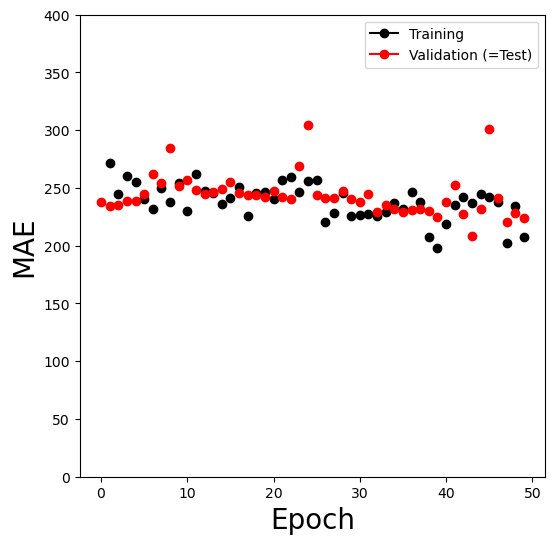

In [278]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax = summary_plot(hit_results,
    ax,
    col='mae',
    ylabel='MAE',
    valid_legend='Validation (=Test)')
ax.set_ylim([0, 400])

In [279]:
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t- preds).mean()

tensor(224.2696, grad_fn=<MeanBackward0>)

In [280]:
del(Hitters,
hit_model, hit_dm,
hit_logger,
hit_test, hit_train,
X, Y,
X_test, X_train,
Y_test, Y_train,
X_test_t, Y_test_t,
hit_trainer, hit_module)

In [281]:
(mnist_train,
mnist_test) = [MNIST(root='data',
train=train,
download=True,
transform=ToTensor())
for train in [True, False]]
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [282]:
mnist_dm = SimpleDataModule(mnist_train,
mnist_test,
validation=0.2,
num_workers=max_num_workers,
batch_size=256)

In [283]:
for idx, (X_ ,Y_) in enumerate(mnist_dm.train_dataloader()):
 print('X: ', X_.shape)
 print('Y: ', Y_.shape)
 if idx >=1:
   break

X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])
X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])


In [284]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.4))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3))
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(128, 10))

    def forward(self, x):
        return self._forward(x)

In [285]:
mnist_model = MNISTModel()

In [286]:
mnist_model(X_).size()

torch.Size([256, 10])

In [287]:
summary(mnist_model,
input_data=X_,
col_names=['input_size',
'output_size',
'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

In [288]:
mnist_module = SimpleModule.classification(mnist_model, num_classes=10)
mnist_logger = CSVLogger('logs', name='MNIST')

In [289]:
mnist_trainer = Trainer(deterministic=True,
max_epochs=30,
logger=mnist_logger,
callbacks=[ErrorTracker()])
mnist_trainer.fit(mnist_module,
datamodule=mnist_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MNISTModel       │  235 K │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=30` reached.


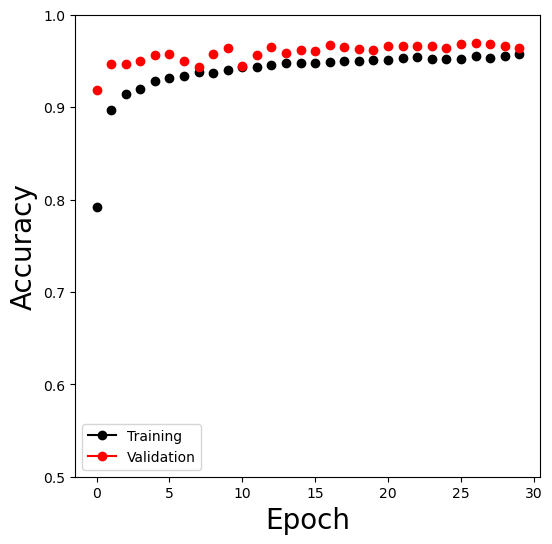

In [290]:
mnist_results = pd.read_csv(mnist_logger.experiment.
metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(mnist_results,
ax,
col='accuracy',
ylabel='Accuracy')
ax.set_ylim([0.5, 1])
ax.set_ylabel('Accuracy')
ax.set_xticks(np.linspace(0, 30, 7).astype(int));

In [291]:
mnist_trainer.test(mnist_module,
datamodule=mnist_dm)

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9646000266075134     │
│         test_loss         │    0.15089471638202667    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.15089471638202667, 'test_accuracy': 0.9646000266075134}]

In [292]:
from ISLP.torch import SimpleModule
from pytorch_lightning.loggers import CSVLogger
import torch.nn as nn

class MNIST_MLR(nn.Module):
    def __init__(self):
        super(MNIST_MLR, self).__init__()
        self.linear = nn.Sequential(nn.Flatten(),
                                    nn.Linear(784, 10))
    def forward(self, x):
        return self.linear(x)

mlr_model = MNIST_MLR()
mlr_module = SimpleModule.classification(mlr_model, num_classes=10)  # not the old line
mlr_logger = CSVLogger('logs', name='MNIST_MLR')


In [293]:
import lightning as L

mlr_trainer = L.Trainer()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [294]:
from torchvision.datasets import CIFAR100

(cifar_train,
 cifar_test) = [CIFAR100(root="data",
                         train=train,
                         download=True)
                for train in [True, False]]

In [295]:
from torchvision.transforms import ToTensor
import torch
from torch.utils.data import TensorDataset

transform = ToTensor()

# Convert raw CIFAR100 data to tensors first
cifar_train_X = torch.stack([transform(x) for x in cifar_train.data])
cifar_test_X  = torch.stack([transform(x) for x in cifar_test.data])

# Wrap into TensorDatasets
cifar_train = TensorDataset(cifar_train_X, torch.tensor(cifar_train.targets))
cifar_test  = TensorDataset(cifar_test_X,  torch.tensor(cifar_test.targets))

# NOW .tensors works, since cifar_train/test are TensorDatasets
cifar_train_X = cifar_train.tensors[0]
cifar_train_y = cifar_train.tensors[1]
cifar_test_X  = cifar_test.tensors[0]
cifar_test_y  = cifar_test.tensors[1]

In [296]:
from torchvision.datasets import CIFAR100
from torchvision.transforms import ToTensor
import torch

# Load datasets
(cifar_train,
 cifar_test) = [CIFAR100(root="data",
                         train=train,
                         download=True)
                for train in [True, False]]

# Apply transforms
transform = ToTensor()
cifar_train_X = torch.stack([transform(x) for x in cifar_train.data])
cifar_test_X = torch.stack([transform(x) for x in cifar_test.data])

In [297]:
!pip install lightning

In [298]:
!pip install pytorch-lightning

In [299]:
import pytorch_lightning as pl

class CIFARDataModule(pl.LightningDataModule):  # swap L. for pl.
    ...

In [300]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import lightning as L  # or: import pytorch_lightning as pl

class CIFARDataModule(L.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=32):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def setup(self, stage=None):
        self.train_dataset = datasets.CIFAR10(
            root=self.data_dir, train=True, download=True, transform=self.transform
        )
        self.val_dataset = datasets.CIFAR10(
            root=self.data_dir, train=False, download=True, transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)


# Instantiate and setup
cifar_dm = CIFARDataModule()
cifar_dm.setup()

# Now this will work
for idx, (X_, Y_) in enumerate(cifar_dm.train_dataloader()):
    print('X: ', X_.shape)
    print('Y: ', Y_.shape)
    break  # remove to iterate all batches

X:  torch.Size([32, 3, 32, 32])
Y:  torch.Size([32])


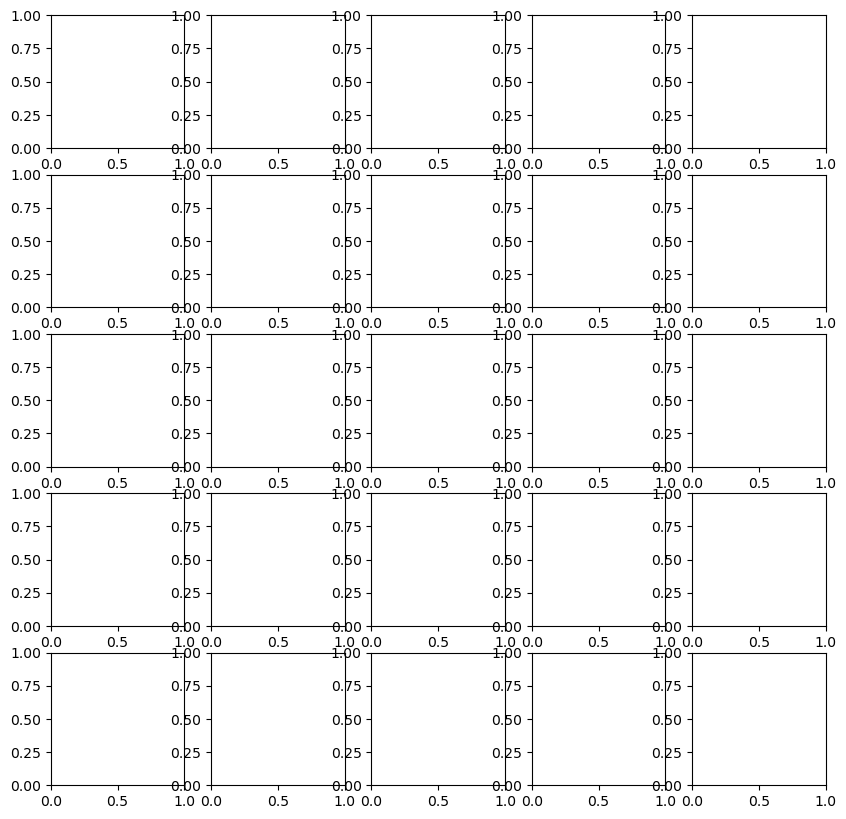

In [301]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load CIFAR-10 training set
cifar_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Now your plotting code will work
fig, axes = plt.subplots(5, 5, figsize=(10,10))
rng = np.random.default_rng(4)
indices = rng.choice(np.arange(len(cifar_train)), 25, replace=False).reshape((5,5))

In [302]:
import torch.nn as nn

class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BuildingBlock, self).__init__()
        
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=(3,3),
            padding='same'
        )
        
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2,2))

    def forward(self, x):
        return self.pool(self.activation(self.conv(x)))

In [303]:
class CIFARModel(nn.Module):
    def __init__(self):
        super(CIFARModel, self).__init__()
        sizes = [(3, 32),
                 (32, 64),
                 (64, 128),
                 (128, 256)]
        self.conv = nn.Sequential(*[BuildingBlock(in_, out_)
                                    for in_, out_ in sizes])
        self.output = nn.Sequential(nn.Dropout(0.5),
                                    nn.Linear(2*2*256, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 100))

    def forward(self, x):
        val = self.conv(x)
        val = torch.flatten(val, start_dim=1)
        return self.output(val)

In [304]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BuildingBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

    def forward(self, x):
        return self.conv(x)



In [305]:
import torch.nn as nn

class CIFARModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.block1 = BuildingBlock(3, 32)
        self.block2 = BuildingBlock(32, 64)
        self.block3 = BuildingBlock(64, 128)

In [306]:
from pytorch_lightning.loggers import CSVLogger

cifar_logger = CSVLogger('logs', name='CIFAR100')


In [307]:
cifar_model = CIFARModel()

In [308]:
from torch.optim import RMSprop
cifar_optimizer = RMSprop(cifar_model.parameters(), lr=0.001)

In [309]:
from ISLP.torch import SimpleModule, SimpleDataModule

cifar_module = SimpleModule.classification(
    cifar_model,
    num_classes=100,
    optimizer=cifar_optimizer
)

In [310]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl

class CIFARModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # Example simple CNN
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*8*8, 256)  # adjust based on input size
        self.fc2 = nn.Linear(256, 10)      # CIFAR-10 has 10 classes

        self.loss = nn.CrossEntropyLoss()

    # 🔹 This is mandatory!
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 32x32 -> 16x16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 16x16 -> 8x8
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self.forward(x)  # call forward
        loss = self.loss(preds, y)
        self.log("train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)



In [311]:
import torch.optim as optim
from ISLP.torch import SimpleModule

# Your model should be defined before this
cifar_optimizer = optim.SGD(cifar_model.parameters(), lr=0.01)

cifar_module = SimpleModule.classification(
    cifar_model,
    num_classes=100,
    optimizer=cifar_optimizer
)

# Verify it's a LightningModule
print(type(cifar_module))

<class 'ISLP.torch.lightning.SimpleModule'>


In [312]:
try:
    # Move metrics to MPS if needed
    for name, metric in cifar_module.metrics.items():
        cifar_module.metrics[name] = metric.to('mps')

    # Setup trainer for MPS
    cifar_trainer_mps = Trainer(
        accelerator='mps',
        deterministic=True,
        max_epochs=30
    )

    # Train and test
    cifar_trainer_mps.fit(cifar_module, datamodule=cifar_dm)
    cifar_trainer_mps.test(cifar_module, datamodule=cifar_dm)

except Exception as e:
    print("Error during training or testing:", e)

Error during training or testing: PyTorch is not linked with support for mps devices


In [313]:
from torchvision.models import resnet50, ResNet50_Weights

resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)

In [314]:
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [315]:
# Example of what it might look like
from glob import glob
imgfiles = glob("your/folder/*.jpg")  # might be missing .png files etc.

In [316]:
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json",
    "imagenet_class_index.json"
)
import json
import pandas as pd

labs = json.load(open('imagenet_class_index.json'))
import json
import pandas as pd

labs = json.load(open('imagenet_class_index.json'))

In [230]:
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json",
    "imagenet_class_index.json"
)

('imagenet_class_index.json', <http.client.HTTPMessage at 0x1a9108ac650>)

In [231]:
 for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df['prob'] = img_probs[i]
    img_df = img_df.sort_values(by='prob', ascending=False)[:3]
    print(f'Image: {imgfile}')
    print(img_df.reset_index().drop(columns=['idx']))

In [232]:
for var in ['cifar_test', 'cifar_train', 'cifar_dm', 
            'cifar_module', 'cifar_logger', 'cifar_trainer']:
    if var in dir():
        del globals()[var]

In [233]:
from ISLP.torch.imdb import load_sequential

(imdb_seq_train,
 imdb_seq_test) = load_sequential(root='data/IMDB')
padded_sample = np.asarray(imdb_seq_train.tensors[0][0])
sample_review = padded_sample[padded_sample > 0][:12]

In [234]:
from ISLP.torch.imdb import load_sequential, load_lookup

lookup = load_lookup(root='data/IMDB')
' '.join(lookup[i] for i in sample_review)

"<START> this film was just brilliant casting location scenery story direction everyone's"

In [235]:
from ISLP.torch.imdb import load_sequential, load_lookup, load_tensor

max_num_workers = 10
(imdb_train,
 imdb_test) = load_tensor(root='data/IMDB')
imdb_dm = SimpleDataModule(imdb_train,
                           imdb_test,
                           validation=2000,
                           num_workers=min(6, max_num_workers),
                           batch_size=512)

In [236]:
class IMDBModel(nn.Module):
    def __init__(self, input_size):
        super(IMDBModel, self).__init__()
        self.dense1 = nn.Linear(input_size, 16)
        self.activation = nn.ReLU()
        self.dense2 = nn.Linear(16, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        val = x
        for _map in [self.dense1,
                     self.activation,
                     self.dense2,
                     self.activation,
                     self.output]:
            val = _map(val)
        return torch.flatten(val)

In [237]:
from ISLP.torch.imdb import load_sequential, load_lookup, load_tensor

max_num_workers = 10
(imdb_train,
 imdb_test) = load_tensor(root='data/IMDB')
imdb_dm = SimpleDataModule(imdb_train,
                           imdb_test,
                           validation=2000,
                           num_workers=min(6, max_num_workers),
                           batch_size=512)

In [238]:
max_length = 500  # replace with your actual sequence length

imdb_model = nn.Sequential(
    nn.Embedding(num_embeddings=10000, embedding_dim=64),
    nn.Flatten(),
    nn.Linear(64 * max_length, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

In [239]:
from ISLP.torch import ErrorTracker


In [240]:
import pytorch_lightning as pl

imdb_module = SimpleModule.binary_classification(imdb_model)
imdb_trainer2 = pl.Trainer(max_epochs=10, accelerator='auto', enable_progress_bar=True)
imdb_trainer2.fit(imdb_module, datamodule=imdb_dm)
test_results = imdb_trainer2.test(imdb_module, datamodule=imdb_dm)
test_results


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential        │  4.7 M │ train │     0 │
│ 1 │ loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:424: UserWarning: This DataLoader 
will create 6 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not
taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive 
worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential 
slowness/freeze if necessary.
  self.check_worker_number_rationality()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:432: UserWarning: This DataLoader 
will create 6 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not
taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive 
worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential 
slowness/freeze if necessary.
  self.check_worker_number_rationality()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training 
batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.FloatTensor instead (while checking arguments for embedding)

In [241]:
((X_train, Y_train),
(X_valid, Y_valid),
(X_test, Y_test)) = load_sparse(validation=2000,
random_state=0,
root='data/IMDB')

In [242]:
X_train = X_train_t
Y_train = Y_train_t

lam_max = np.abs(X_train.T @ (Y_train - Y_train.mean())).max()
lam_val = lam_max * np.exp(np.linspace(np.log(1), np.log(1e-4), 50))

C:\Users\DIGITAL AXIS\AppData\Local\Temp\ipykernel_5528\534412362.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lam_max = np.abs(X_train.T @ (Y_train - Y_train.mean())).max()
C:\Users\DIGITAL AXIS\AppData\Local\Temp\ipykernel_5528\534412362.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lam_val = lam_max * np.exp(np.linspace(np.log(1), np.log(1e-4), 50))


In [243]:
logit = LogisticRegression(penalty='l1',
C=1/lam_max,
solver='liblinear',
warm_start=True,
fit_intercept=True)

In [244]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(penalty='l1', solver='liblinear', warm_start=True)

In [245]:
import numpy as np
from sklearn.linear_model import LogisticRegression

X_train = X_train_t.numpy()
Y_continuous = Y_train_t.numpy()

# Binarize around the median (or use a meaningful threshold)
Y_train = (Y_continuous > np.median(Y_continuous)).astype(int)

logit = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
coefs = []
intercepts = []

for l in lam_val:
    logit.C = float(1/l)
    logit.fit(X_train, Y_train)
    coefs.append(logit.coef_.copy())
    intercepts.append(logit.intercept_)



In [246]:
coefs = np.squeeze(coefs)
intercepts = np.squeeze(intercepts)

In [317]:
# Convert sparse matrix to dense if needed
X_train_dense = np.asarray(X_train.todense())
X_valid_dense = np.asarray(X_valid.todense())
X_test_dense  = np.asarray(X_test.todense())

coefs_arr = np.array(coefs).squeeze()      # (50, n_features)
intercepts_arr = np.array(intercepts)      # (50, 1)

fig, axes = subplots(1, 2, figsize=(16, 8), sharey=True)

for (X_, Y_), data_, color in zip(
        [(X_train_dense, Y_train),
         (X_valid_dense, Y_valid),
         (X_test_dense,  Y_test)],
        ['Training', 'Validation', 'Test'],
        ['black', 'red', 'blue']):
    linpred_ = X_ @ coefs_arr.T + intercepts_arr.T
    label_ = np.array(linpred_ > 0)
    accuracy_ = np.array([np.mean(Y_ == l) for l in label_.T])
    axes[0].plot(-np.log(lam_val / X_train_dense.shape[0]),
                 accuracy_, '.--', color=color,
                 markersize=13, linewidth=2, label=data_)

axes[0].legend()
axes[0].set_xlabel(r'$-\log(\lambda)$', fontsize=20)
axes[0].set_ylabel('Accuracy', fontsize=20)
plt.show()

NameError: name 'X_train' is not defined

In [319]:
from sklearn.model_selection import train_test_split

# Rebuild X_train/valid/test from Hitters data
X_all = X_train_t.numpy()
Y_continuous = Y_train_t.numpy()
Y_all = (Y_continuous > np.median(Y_continuous)).astype(int)

X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X_all, Y_all, test_size=0.2, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X_trainval, Y_trainval, test_size=0.2, random_state=0)

# Refit logistic regression
logit = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
coefs, intercepts = [], []
for l in lam_val:
    logit.C = float(1/l)
    logit.fit(X_train, Y_train)
    coefs.append(logit.coef_.copy())
    intercepts.append(logit.intercept_)

# Plot
coefs_arr = np.array(coefs).squeeze()
intercepts_arr = n

In [320]:
from pytorch_lightning.loggers import CSVLogger

imdb_logger = CSVLogger('logs', name='imdb')
imdb_module = SimpleModule.binary_classification(imdb_model)
imdb_trainer2 = pl.Trainer(max_epochs=10, accelerator='auto', 
                            enable_progress_bar=True, logger=imdb_logger)
imdb_trainer2.fit(imdb_module, datamodule=imdb_dm)
test_results = imdb_trainer2.test(imdb_module, datamodule=imdb_dm)

# Now read results
imdb_results = pd.read_csv(imdb_logger.experiment.metrics_file_path)
summary_plot(imdb_results, axes[1], col='accuracy', ylabel='Accuracy')
axes[1].set_xticks(np.linspace(0, 30, 7).astype(int))
imdb_results = pd.read_csv(imdb_logger.experiment.metrics_file_path)
summary_plot(imdb_results,
axes[1],
col='accuracy',
ylabel='Accuracy')
axes[1].set_xticks(np.linspace(0, 30, 7).astype(int))
axes[1].set_ylabel('Accuracy', fontsize=20)
axes[1].set_xlabel('Epoch', fontsize=20)
axes[1].set_ylim([0.5, 1]);
axes[1].axhline(test_results[0]['test_accuracy'],
color='blue',
linestyle='--',
linewidth=3)
fig

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential        │  4.7 M │ train │     0 │
│ 1 │ loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:424: UserWarning: This DataLoader 
will create 6 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not
taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive 
worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential 
slowness/freeze if necessary.
  self.check_worker_number_rationality()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:432: UserWarning: This DataLoader 
will create 6 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not
taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive 
worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential 
slowness/freeze if necessary.
  self.check_worker_number_rationality()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training 
batches (45) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.FloatTensor instead (while checking arguments for embedding)

In [322]:
for var in ['imdb_model', 'imdb_trainer', 'imdb_logger', 
            'imdb_dm', 'imdb_train', 'imdb_test']:
    if var in globals():
        del globals()[var]

In [323]:
imdb_seq_dm = SimpleDataModule(imdb_seq_train,
imdb_seq_test,
validation=2000,
batch_size=300,
num_workers=min(6, max_num_workers)
)

In [324]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_size, 32)
        self.lstm = nn.LSTM(input_size=32,
                            hidden_size=32,
                            batch_first=True)
        self.dense = nn.Linear(32, 1)

    def forward(self, x):
        val, (h_n, c_n) = self.lstm(self.embedding(x))
        return torch.flatten(self.dense(val[:, -1]))

In [325]:
lstm_model = LSTMModel(10000)
summary(lstm_model,
        input_data=imdb_seq_train.tensors[0][:10],
        col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMModel                                [10, 500]                 [10]                      --
├─Embedding: 1-1                         [10, 500]                 [10, 500, 32]             320,000
├─LSTM: 1-2                              [10, 500, 32]             [10, 500, 32]             8,448
├─Linear: 1-3                            [10, 32]                  [10, 1]                   33
Total params: 328,481
Trainable params: 328,481
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 45.44
Input size (MB): 50.00
Forward/backward pass size (MB): 2.56
Params size (MB): 1.31
Estimated Total Size (MB): 53.87

In [326]:
lstm_module = SimpleModule.binary_classification(lstm_model)
lstm_logger = CSVLogger('logs', name='IMDB_LSTM')

In [327]:
lstm_trainer = Trainer(deterministic=True,
max_epochs=20,
logger=lstm_logger,
callbacks=[ErrorTracker()])
lstm_trainer.fit(lstm_module,
datamodule=imdb_seq_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LSTMModel         │  328 K │ train │     0 │
│ 1 │ loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 328 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 328 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

IndexError: index out of range in self

In [328]:
from pytorch_lightning.loggers import CSVLogger

lstm_model = LSTMModel(10000)  # correct vocab size
lstm_module = SimpleModule.binary_classification(lstm_model)
lstm_logger = CSVLogger('logs', name='lstm')
lstm_trainer = pl.Trainer(max_epochs=10, accelerator='auto',
                          enable_progress_bar=True, logger=lstm_logger)
lstm_trainer.fit(lstm_module, datamodule=imdb_seq_dm)
lstm_trainer.test(lstm_module, datamodule=imdb_seq_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LSTMModel         │  328 K │ train │     0 │
│ 1 │ loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 328 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 328 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

IndexError: index out of range in self

In [329]:
import glob
files = glob.glob('logs/**/*.csv', recursive=True)
print(files)

['logs\\CIFAR\\version_0\\metrics.csv', 'logs\\hitters\\version_0\\metrics.csv', 'logs\\hitters\\version_1\\metrics.csv', 'logs\\hitters\\version_10\\metrics.csv', 'logs\\hitters\\version_11\\metrics.csv', 'logs\\hitters\\version_12\\metrics.csv', 'logs\\hitters\\version_13\\metrics.csv', 'logs\\hitters\\version_14\\metrics.csv', 'logs\\hitters\\version_15\\metrics.csv', 'logs\\hitters\\version_2\\metrics.csv', 'logs\\hitters\\version_3\\metrics.csv', 'logs\\hitters\\version_4\\metrics.csv', 'logs\\hitters\\version_5\\metrics.csv', 'logs\\hitters\\version_6\\metrics.csv', 'logs\\hitters\\version_7\\metrics.csv', 'logs\\hitters\\version_8\\metrics.csv', 'logs\\hitters\\version_9\\metrics.csv', 'logs\\IMDB\\version_0\\metrics.csv', 'logs\\IMDB_LSTM\\version_0\\metrics.csv', 'logs\\MNIST\\version_0\\metrics.csv', 'logs\\MNIST\\version_1\\metrics.csv', 'logs\\MNIST\\version_10\\metrics.csv', 'logs\\MNIST\\version_11\\metrics.csv', 'logs\\MNIST\\version_12\\metrics.csv', 'logs\\MNIST\\versi

In [330]:
 for var in ['lstm_model', 'lstm_trainer', 'lstm_logger', 
            'imdb_seq_dm', 'imdb_seq_train', 'imdb_seq_test']:
    if var in dir():
        del globals()[var]

In [331]:
NYSE = load_data('NYSE')
cols = ['DJ_return', 'log_volume', 'log_volatility']
X = pd.DataFrame(StandardScaler(
with_mean=True,
with_std=True).fit_transform(NYSE[cols]),
columns=NYSE[cols].columns,
index=NYSE.index)


In [332]:
# Reset X to its original state before adding lag columns
X = NYSE[cols].copy()  # or however X was originally defined

for lag in range(1, 6):
    for col in cols:
        newcol = np.zeros(X.shape[0]) * np.nan
        newcol[lag:] = X[col].values[:-lag]
        X.insert(len(X.columns), "{0}_{1}".format(col, lag), newcol)

X.insert(len(X.columns), 'train', NYSE['train'])
X = X.dropna()

In [333]:
cols = ['DJ_return', 'log_volume', 'log_volatility']  # adjust if your cols differ
X = NYSE[cols].copy()

for lag in range(1, 6):
    for col in cols:
        newcol = np.zeros(X.shape[0]) * np.nan
        newcol[lag:] = X[col].values[:-lag]
        X.insert(len(X.columns), "{0}_{1}".format(col, lag), newcol)

X.insert(len(X.columns), 'train', NYSE['train'])
X = X.dropna()

Y, train = X['log_volume'], X['train']
X = X.drop(columns=['train'] + cols)
X.columns

Index(['DJ_return_1', 'log_volume_1', 'log_volatility_1', 'DJ_return_2',
       'log_volume_2', 'log_volatility_2', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_4', 'log_volume_4', 'log_volatility_4',
       'DJ_return_5', 'log_volume_5', 'log_volatility_5'],
      dtype='object')

In [334]:
from sklearn.linear_model import LinearRegression

M = LinearRegression()
M.fit(X[train], Y[train])
M.score(X[train], Y[train])



0.57071503921461

In [335]:
from ISLP import load_data
NYSE = load_data('NYSE')

dummies = pd.get_dummies(NYSE['day_of_week'])
dummies.columns = dummies.columns.astype(str)
X_day = pd.merge(X, dummies, left_index=True, right_index=True)

In [336]:
from sklearn.linear_model import LinearRegression

M = LinearRegression()
M.fit(X_day[train], Y[train])
M.score(X_day[train], Y[train])

0.5997186642858012

In [337]:
cols = ['DJ_return', 'log_volume', 'log_volatility']

ordered_cols = []
for lag in range(5, 0, -1):
    for col in cols:
        ordered_cols.append('{0}_{1}'.format(col, lag))

X = X.reindex(columns=ordered_cols)
X.columns

Index(['DJ_return_5', 'log_volume_5', 'log_volatility_5', 'DJ_return_4',
       'log_volume_4', 'log_volatility_4', 'DJ_return_3', 'log_volume_3',
       'log_volatility_3', 'DJ_return_2', 'log_volume_2', 'log_volatility_2',
       'DJ_return_1', 'log_volume_1', 'log_volatility_1'],
      dtype='object')

In [338]:
from ISLP import load_data
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

NYSE = load_data('NYSE')
cols = ['DJ_return', 'log_volume', 'log_volatility']
X = NYSE[cols].copy()

for lag in range(1, 6):
    for col in cols:
        newcol = np.zeros(X.shape[0]) * np.nan
        newcol[lag:] = X[col].values[:-lag]
        X.insert(len(X.columns), "{0}_{1}".format(col, lag), newcol)

X.insert(len(X.columns), 'train', NYSE['train'])
X = X.dropna()

Y, train = X['log_volume'], X['train']
X = X.drop(columns=['train'] + cols)

ordered_cols = []
for lag in range(5, 0, -1):
    for col in cols:
        ordered_cols.append('{0}_{1}'.format(col, lag))

X = X.reindex(columns=ordered_cols)

X_rnn = X.to_numpy().reshape((-1, 5, 3))
X_rnn.shape

(6046, 5, 3)

In [339]:
class NYSEModel(nn.Module):
    def __init__(self):
        super(NYSEModel, self).__init__()
        self.rnn = nn.RNN(3,
                          12,
                          batch_first=True)
        self.dense = nn.Linear(12, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        val, h_n = self.rnn(x)
        val = self.dense(self.dropout(val[:, -1]))
        return torch.flatten(val)

nyse_model = NYSEModel()

In [340]:
datasets = []
for mask in [train, ~train]:
    X_rnn_t = torch.tensor(X_rnn[mask].astype(np.float32))
    Y_t = torch.tensor(Y[mask].values.astype(np.float32))
    datasets.append(TensorDataset(X_rnn_t, Y_t))

nyse_train, nyse_test = datasets

In [341]:
from torchinfo import summary

summary(nyse_model,
        input_data=X_rnn_t,
        col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
NYSEModel                                [1770, 5, 3]              [1770]                    --
├─RNN: 1-1                               [1770, 5, 3]              [1770, 5, 12]             204
├─Dropout: 1-2                           [1770, 12]                [1770, 12]                --
├─Linear: 1-3                            [1770, 12]                [1770, 1]                 13
Total params: 217
Trainable params: 217
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.11
Forward/backward pass size (MB): 0.86
Params size (MB): 0.00
Estimated Total Size (MB): 0.97

In [342]:
import torch
from torch.utils.data import TensorDataset
from ISLP.torch.lightning import SimpleDataModule

X_rnn_t = torch.tensor(X_rnn, dtype=torch.float32)
Y_t = torch.tensor(Y.values, dtype=torch.float32)
train_t = torch.tensor(train.values, dtype=torch.bool)

nyse_train = TensorDataset(X_rnn_t[train_t], Y_t[train_t])
nyse_test = TensorDataset(X_rnn_t[~train_t], Y_t[~train_t])

nyse_dm = SimpleDataModule(nyse_train,
                           nyse_test,
                           num_workers=min(4, max_num_workers),
                           validation=nyse_test,
                           batch_size=64)

In [343]:
nyse_dm = SimpleDataModule(nyse_train,
                           nyse_test,
                           num_workers=min(4, max_num_workers),
                           validation=nyse_test,
                           batch_size=64)

for idx, (x, y) in enumerate(nyse_dm.train_dataloader()):
    out = nyse_model(x)
    print(y.size(), out.size())
    if idx >= 2:
        break

torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])
torch.Size([64]) torch.Size([64])


In [344]:
from torchmetrics.regression import R2Score

nyse_optimizer = RMSprop(nyse_model.parameters(), lr=0.001)
nyse_module = SimpleModule.regression(nyse_model,
                                      optimizer=nyse_optimizer,
                                      metrics={'r2': R2Score()})

In [345]:
#import warnings
#warnings.filter('ignore warnings')
nyse_trainer = Trainer(deterministic=True,
max_epochs=200,
callbacks=[ErrorTracker()])
nyse_trainer.fit(nyse_module,
datamodule=nyse_dm)
nyse_trainer.test(nyse_module,
datamodule=nyse_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ NYSEModel │    217 │ train │     0 │
│ 1 │ loss  │ MSELoss   │      0 │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 217                                                                                              
Non-trainable params: 0                                                                                            
Total params: 217                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=200` reached.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.03392287716269493    │
│          test_r2          │    0.41035109758377075    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.03392287716269493, 'test_r2': 0.41035109758377075}]

In [346]:
datasets = []
for mask in [train, ~train]:
    X_day_t = torch.tensor(np.asarray(X_day[mask]).astype(np.float32))
    Y_t = torch.tensor(np.asarray(Y[mask]).astype(np.float32))
    datasets.append(TensorDataset(X_day_t, Y_t))

day_train, day_test = datasets

In [347]:
day_dm = SimpleDataModule(day_train,
day_test,
num_workers=min(4, max_num_workers),
validation=day_test,
batch_size=64)

In [348]:
%matplotlib inline

class NonLinearARModel(nn.Module):
    def __init__(self):
        super(NonLinearARModel, self).__init__()
        self._forward = nn.Sequential(nn.Flatten(),
                                      nn.Linear(20, 32),
                                      nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(32, 1))
    def forward(self, x):
        return torch.flatten(self._forward(x))

In [349]:
%matplotlib inline
nl_model = NonLinearARModel()
nl_optimizer = RMSprop(nl_model.parameters(),
lr=0.001)
nl_module = SimpleModule.regression(nl_model,
optimizer=nl_optimizer,
metrics={'r2':R2Score()})


In [350]:
import torch
from torch.utils.data import TensorDataset
from ISLP.torch.lightning import SimpleDataModule

# Redefine nyse datasets
X_rnn_t = torch.tensor(X_rnn, dtype=torch.float32)
Y_t = torch.tensor(Y.values, dtype=torch.float32)
train_t = torch.tensor(train.values, dtype=torch.bool)

nyse_train = TensorDataset(X_rnn_t[train_t], Y_t[train_t])
nyse_test = TensorDataset(X_rnn_t[~train_t], Y_t[~train_t])

# Use day_train/day_test for the day-of-week model
nl_model = NonLinearARModel()
nl_module = SimpleModule.regression(nl_model)
day_dm = SimpleDataModule(day_train, day_test, batch_size=32)

nl_trainer = pl.Trainer(deterministic=True, max_epochs=20,
                        callbacks=[ErrorTracker()])
nl_trainer.fit(nl_module, datamodule=day_dm)
nl_trainer.test(nl_module, datamodule=day_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ NonLinearARModel │    705 │ train │     0 │
│ 1 │ loss  │ MSELoss          │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 705                                                                                              
Non-trainable params: 0                                                                                            
Total params: 705                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

...

`Trainer.fit` stopped: `max_epochs=20` reached.


Output()

C:\Users\DIGITAL AXIS\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.04478863254189491    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.04478863254189491}]